In [ ]:
# Add src to path to allow importing net_epistemology without installing the package
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Basic Testing

In this notebook we test that the main files work well.

## Setup

In [1]:
from net_epistemology.utils.imports import *
from net_epistemology.core.agents import BetaAgent, BayesAgent
from net_epistemology.core.model import Model

## Try with Bayes Agent

In [2]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

In [3]:
seed=420
my_model = Model(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True) #number_of_steps is a max amount\n",
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)
# df = pd.DataFrame(my_model.agent_histories)
# df.head(3)

100%|██████████| 10000/10000 [00:26<00:00, 372.73it/s]

steps:  10000
conclusion:  0.94
conclusion core 0.94


In [ ]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
df_bayes = pd.DataFrame(my_model.agent_histories).T
df_bayes.head(3)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent

In [4]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

In [5]:
seed=420
my_model = Model(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True) #number_of_steps is a max amount\n",
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
df = pd.DataFrame(my_model.agent_histories)
df.head(3)

100%|██████████| 10000/10000 [05:08<00:00, 32.36it/s]


steps:  10000
conclusion:  0.71


,0,1,2,3,4,5,6,7,8,9,...,19991,19992,19993,19994,19995,19996,19997,19998,19999,20000
0,"[0.9731003909876303, 0.9999577654408789]","[0.6600952197979583, 0.9999577654408789]","[0.6600952197979583, 0.4393665989028639]","[0.5144121155952348, 0.4393665989028639]","[0.5144121155952348, 0.5113180679886309]","[0.5445103848255242, 0.5113180679886309]","[0.5445103848255242, 0.4878035813671599]","[0.5198967301098444, 0.4878035813671599]","[0.5198967301098444, 0.4968516066975525]","[0.5334285722964839, 0.4968516066975525]",...,"[0.499379845697707, 0.5005180084693137]","[0.499379845697707, 0.5003447672164042]","[0.4990878519822906, 0.5003447672164042]","[0.4990878519822906, 0.50024060844471]","[0.5001869343197337, 0.50024060844471]","[0.5001869343197337, 0.5005771572555032]","[0.4986200742742712, 0.5005771572555032]","[0.4986200742742712, 0.5000529353626102]","[0.49918215327957743, 0.5000529353626102]","[0.49918215327957743, 0.5000840153550848]"
1,"[0.6304413459490708, 0.5026277279521519]","[0.5726261688391455, 0.5026277279521519]","[0.5726261688391455, 0.5991873388357339]","[0.5466037758030777, 0.5991873388357339]","[0.5466037758030777, 0.5225912976261005]","[0.49403428593490306, 0.5225912976261005]","[0.49403428593490306, 0.5002904930030769]","[0.4929697614503638, 0.5002904930030769]","[0.4929697614503638, 0.5376000826801278]","[0.48067515125654675, 0.5376000826801278]",...,"[0.49991869532007427, 0.5006600436847427]","[0.49991869532007427, 0.5009996976104074]","[0.499844572684691, 0.5009996976104074]","[0.499844572684691, 0.5007562942538945]","[0.4998891474414408, 0.5007562942538945]","[0.4998891474414408, 0.5008496797577701]","[0.4989992643165973, 0.5008496797577701]","[0.4989992643165973, 0.5009028095033881]","[0.5009280350283498, 0.5009028095033881]","[0.5009280350283498, 0.5003273882170239]"
2,"[0.22476927869542732, 0.6038765766154386]","[0.45361734316853036, 0.6038765766154386]","[0.45361734316853036, 0.36404422676356296]","[0.5373440746510957, 0.36404422676356296]","[0.5373440746510957, 0.46355774955537976]","[0.5082072011859045, 0.46355774955537976]","[0.5082072011859045, 0.5220303811841378]","[0.45054635839137713, 0.5220303811841378]","[0.45054635839137713, 0.4942949044603678]","[0.5439625910521857, 0.4942949044603678]",...,"[0.4988430351498744, 0.5007055380413841]","[0.4988430351498744, 0.5000620443658509]","[0.4995409517475078, 0.5000620443658509]","[0.4995409517475078, 0.5001123429288784]","[0.5001232625510158, 0.5001123429288784]","[0.5001232625510158, 0.5006338753036449]","[0.4994810137617018, 0.5006338753036449]","[0.4994810137617018, 0.500701589630932]","[0.4992892309326595, 0.500701589630932]","[0.4992892309326595, 0.5010878050931734]"


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_1622/4148286619.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x_means = df.applymap(lambda pair: pair[0]).mean()
/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_1622/4148286619.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  y_means = df.applymap(lambda pair: pair[1]).mean()


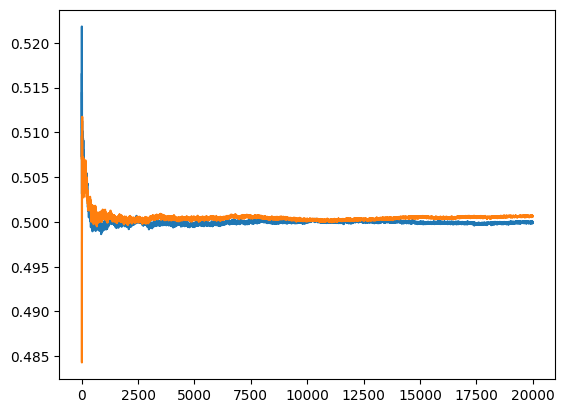

In [6]:
#Extract the first coordinate (x) for each pair and calculate column-wise mean
x_means = df.map(lambda pair: pair[0]).mean()
y_means = df.map(lambda pair: pair[1]).mean()
plt.plot(x_means)
plt.plot(y_means)

/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_1622/44276281.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x_values = df.applymap(lambda pair: pair[0])


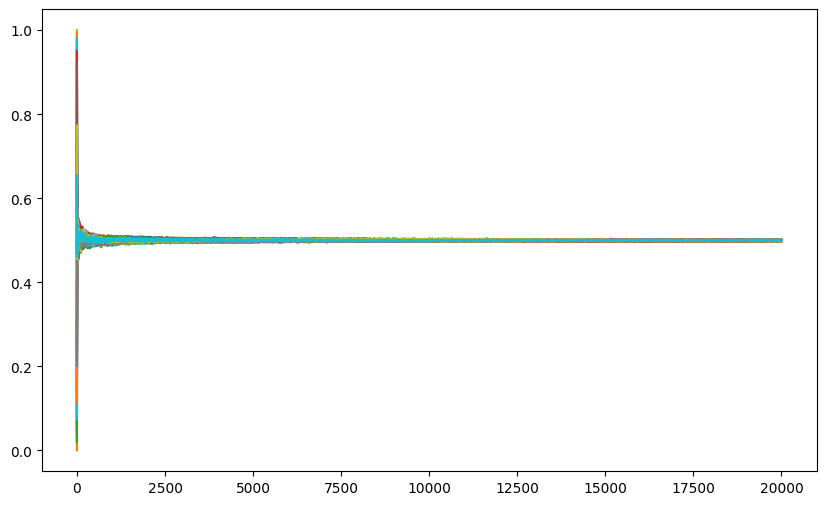

In [7]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row
plt.figure(figsize=(10, 6))
for row_idx in range(x_values.shape[0]):
    plt.plot(x_values.columns, x_values.iloc[row_idx, :], label=f'Row {row_idx+1}' if row_idx < 5 else None)